# Problem C — Binary Classification: IBM vs Other Myositis (DM / PM)
**Local execution version** — based on Burlina et al. (2017) group definitions.

Set `BASE_DIR` in Configuration to your local data folder.

In [1]:
import os, json, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')
print("TF version:", tf.__version__)

TF version: 2.20.0


## Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────
BASE_DIR    = r'.'                                 # <-- CHANGE IF NEEDED
EXCEL_PATH  = os.path.join(BASE_DIR, 'PatientImages_MATCHED.xlsx')
IMAGE_DIR   = os.path.join(BASE_DIR, 'processed_images')
RESULTS_DIR = os.path.join(BASE_DIR, 'results_C')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hyper-params ────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 32
LEARNING_RATE = 1e-5
EPOCHS        = 50
UNFREEZE_LAYERS = 80
SEED          = 42

MODELS_TO_RUN = ["ResNet50", "ResNet101", "EfficientNetB0",
                 "EfficientNetB4", "DenseNet121", "InceptionV3", "Xception"]

## Load & Label Data
**Classes:** DM (D) and PM (P) → label 0 (Other Myositis), IBM (I) → label 1

> This follows the same grouping as Burlina et al. 2017.

In [3]:
df = pd.read_excel(EXCEL_PATH)
diag_col  = [c for c in df.columns if "diagn" in c.lower()][0]
image_col = [c for c in df.columns if c.strip().lower() == 'filename'] or \
            [c for c in df.columns if "image" in c.lower() or "file" in c.lower()]
image_col = image_col[0]

# Problem C: IBM (I) vs other myositis types (DM=D, PM=P)
df_c = df[df[diag_col].isin(['D', 'P', 'I'])].copy()
df_c['label'] = df_c[diag_col].map({'D': 0, 'P': 0, 'I': 1})  # DM/PM=0, IBM=1
df_c['path']  = df_c[image_col].apply(lambda f: os.path.join(IMAGE_DIR, str(f)))
df_c = df_c[df_c['path'].apply(os.path.exists)].reset_index(drop=True)
print(f"Valid images: {len(df_c)}")
print(df_c['label'].value_counts().rename({0:'DM/PM (Other)', 1:'IBM'}))

Valid images: 340
label
IBM              206
DM/PM (Other)    134
Name: count, dtype: int64


## Train / Val / Test Split

In [4]:
train_df, temp_df = train_test_split(df_c, test_size=0.3, stratify=df_c['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
CLASS_NAMES = ['DM/PM', 'IBM']

Train: 238  Val: 51  Test: 51


## Build Datasets, Augmentation & Class Weights

In [5]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.04, 0.04),
], name="augmentation")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(dataframe, augment=False, shuffle=False):
    paths  = dataframe['path'].values
    labels = dataframe['label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle: ds = ds.shuffle(1024)
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

cw = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weight = dict(enumerate(cw))
print("Class weights:", class_weight)

train_ds = make_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,  augment=False, shuffle=False)
test_ds  = make_dataset(test_df, augment=False, shuffle=False)
print("Datasets ready.")

Class weights: {0: np.float64(1.2659574468085106), 1: np.float64(0.8263888888888888)}
Datasets ready.


## Model Definitions

In [6]:
def get_base(name):
    kw = dict(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    return {
        'ResNet50':       keras.applications.ResNet50(**kw),
        'ResNet101':      keras.applications.ResNet101(**kw),
        'EfficientNetB0': keras.applications.EfficientNetB0(**kw),
        'EfficientNetB4': keras.applications.EfficientNetB4(**kw),
        'DenseNet121':    keras.applications.DenseNet121(**kw),
        'InceptionV3':    keras.applications.InceptionV3(**kw),
        'Xception':       keras.applications.Xception(**kw),
    }[name]

def build_binary_model(model_name):
    base = get_base(model_name)
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-UNFREEZE_LAYERS:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model   = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

## Train All Models & Evaluate


  Training: ResNet50

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5294 - auc: 0.4811 - loss: 0.7537 - val_accuracy: 0.3922 - val_auc: 0.5944 - val_loss: 0.7202 - learning_rate: 1.0000e-05
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4958 - auc: 0.5495 - loss: 0.6986 - val_accuracy: 0.6078 - val_auc: 0.6000 - val_loss: 0.6897 - learning_rate: 1.0000e-05
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5042 - auc: 0.5246 - loss: 0.6957 - val_accuracy: 0.6078 - val_auc: 0.7766 - val_loss: 0.6822 - learning_rate: 1.0000e-05
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5294 - auc: 0.5172 - loss: 0.6995 - val_accuracy: 0.6078 - val_auc: 0.6887 - val_loss: 0.6890 - learning_rate: 1.0000e-05
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.4958 - auc: 0.5222 - loss: 0.6956 - val_accuracy: 0.8039 - val_auc: 0.6387 - val_loss: 0.6908 - learning_rate: 1.0000e-05
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accurac

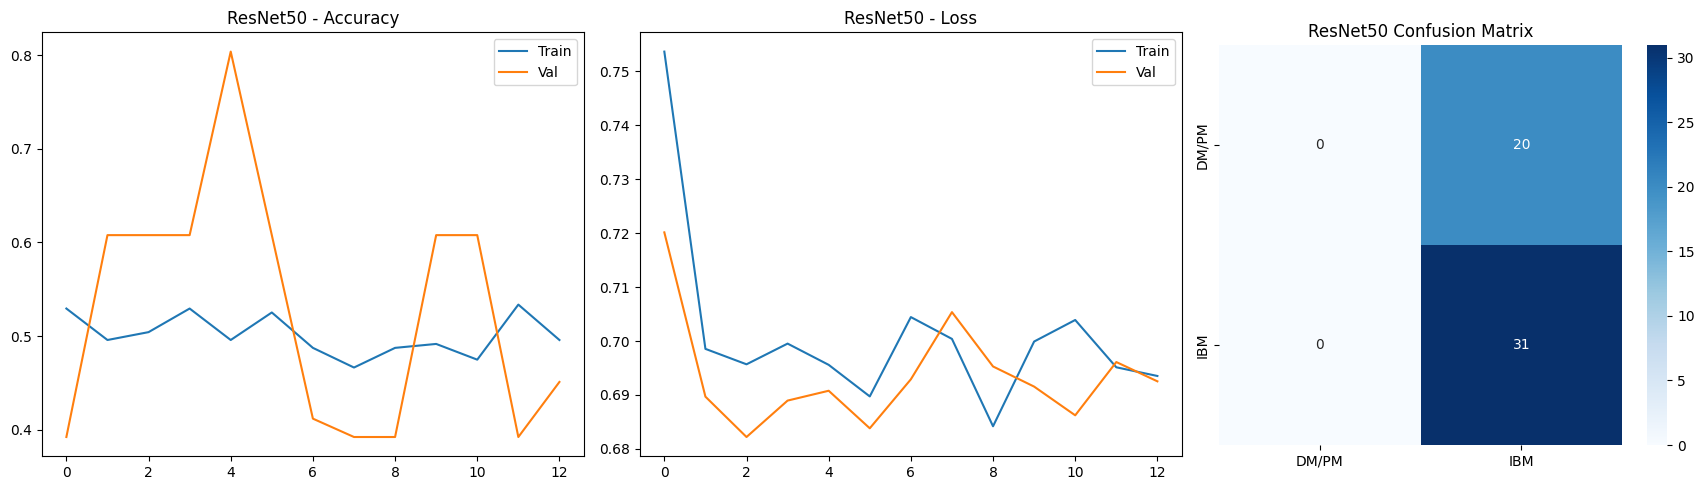

              precision    recall  f1-score   support

       DM/PM       0.00      0.00      0.00        20
         IBM       0.61      1.00      0.76        31

    accuracy                           0.61        51
   macro avg       0.30      0.50      0.38        51
weighted avg       0.37      0.61      0.46        51

{
  "model": "ResNet50",
  "test_acc": 0.6078,
  "test_auc": 0.6532,
  "f1_macro": 0.378,
  "best_val_acc": 0.8039,
  "best_val_auc": 0.7766,
  "epochs": 13
}

  Training: ResNet101
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 55s 5s/step - accuracy: 0.5672 - auc: 0.5735 - loss: 0.7104 - val_accuracy: 0.3922 - val_auc: 0.7379 - val_loss: 0.7339 - learning_rate: 1.0000e-05
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.5210 - auc: 0.5121 - loss: 0.7131 - val_accuracy: 0.6078 - val_auc: 0.6460 - val_loss: 0.6718 - learning_rate: 1.0000e-05
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5798 - auc: 0.5117 - loss: 0.7124 - val_accuracy: 0.3922 - va

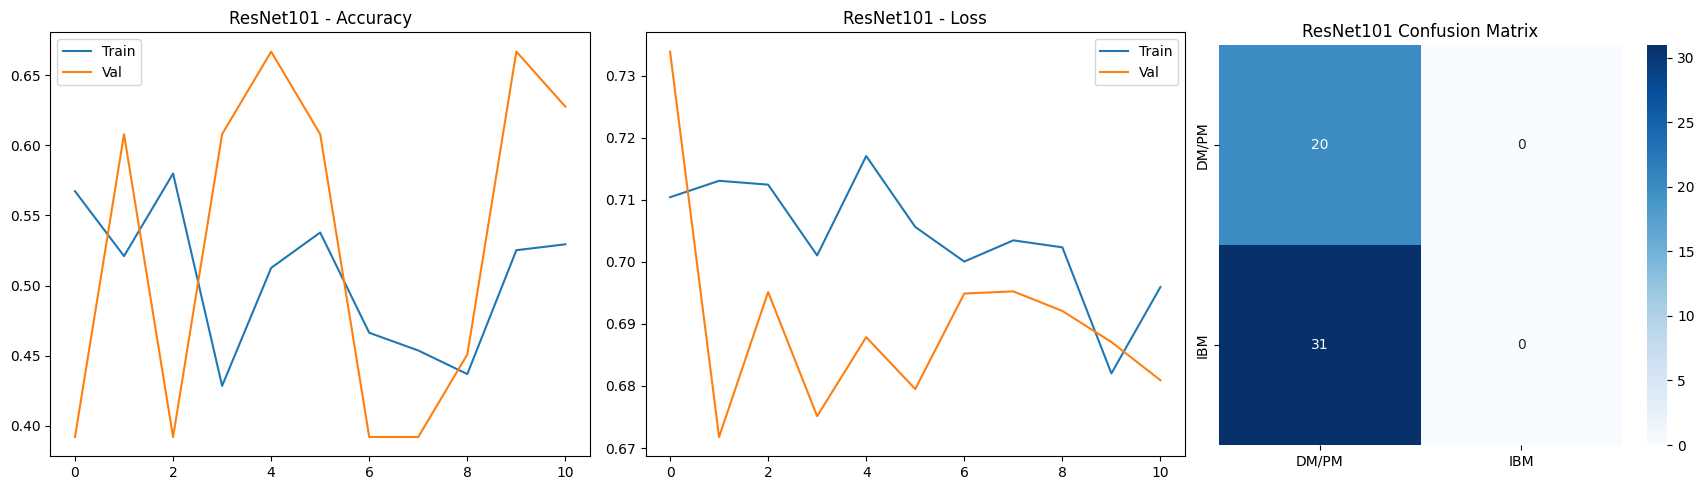

              precision    recall  f1-score   support

       DM/PM       0.39      1.00      0.56        20
         IBM       0.00      0.00      0.00        31

    accuracy                           0.39        51
   macro avg       0.20      0.50      0.28        51
weighted avg       0.15      0.39      0.22        51

{
  "model": "ResNet101",
  "test_acc": 0.3922,
  "test_auc": 0.6565,
  "f1_macro": 0.2817,
  "best_val_acc": 0.6667,
  "best_val_auc": 0.7379,
  "epochs": 11
}

  Training: EfficientNetB0
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5420 - auc: 0.5163 - loss: 0.6928 - val_accuracy: 0.6078 - val_auc: 0.5000 - val_loss: 0.6878 - learning_rate: 1.0000e-05
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 792ms/step - accuracy: 0.5546 - auc: 0.5402 - loss: 0.6910 - val_accuracy: 0.3922 - val_auc: 0.5000 - val_loss: 0.7008 - learning_rate: 1.0000e-05
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4496 - auc: 0.4551 - loss: 0.7033 - val_accuracy: 0.3

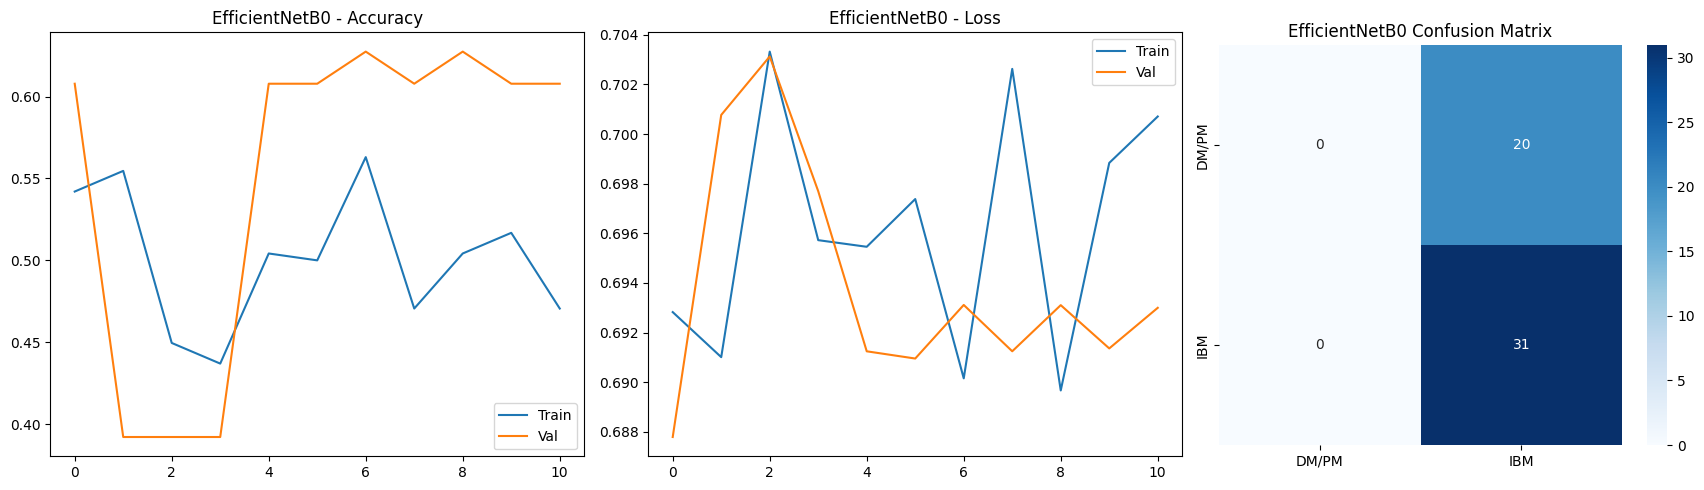

              precision    recall  f1-score   support

       DM/PM       0.00      0.00      0.00        20
         IBM       0.61      1.00      0.76        31

    accuracy                           0.61        51
   macro avg       0.30      0.50      0.38        51
weighted avg       0.37      0.61      0.46        51

{
  "model": "EfficientNetB0",
  "test_acc": 0.6078,
  "test_auc": 0.5,
  "f1_macro": 0.378,
  "best_val_acc": 0.6275,
  "best_val_auc": 0.5,
  "epochs": 11
}

  Training: EfficientNetB4
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.4622 - auc: 0.4778 - loss: 0.6974 - val_accuracy: 0.3922 - val_auc: 0.7371 - val_loss: 0.7010 - learning_rate: 1.0000e-05
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5378 - auc: 0.5133 - loss: 0.6959 - val_accuracy: 0.3922 - val_auc: 0.5161 - val_loss: 0.6942 - learning_rate: 1.0000e-05
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5126 - auc: 0.4989 - loss: 0.6969 - val_accuracy: 0.3922

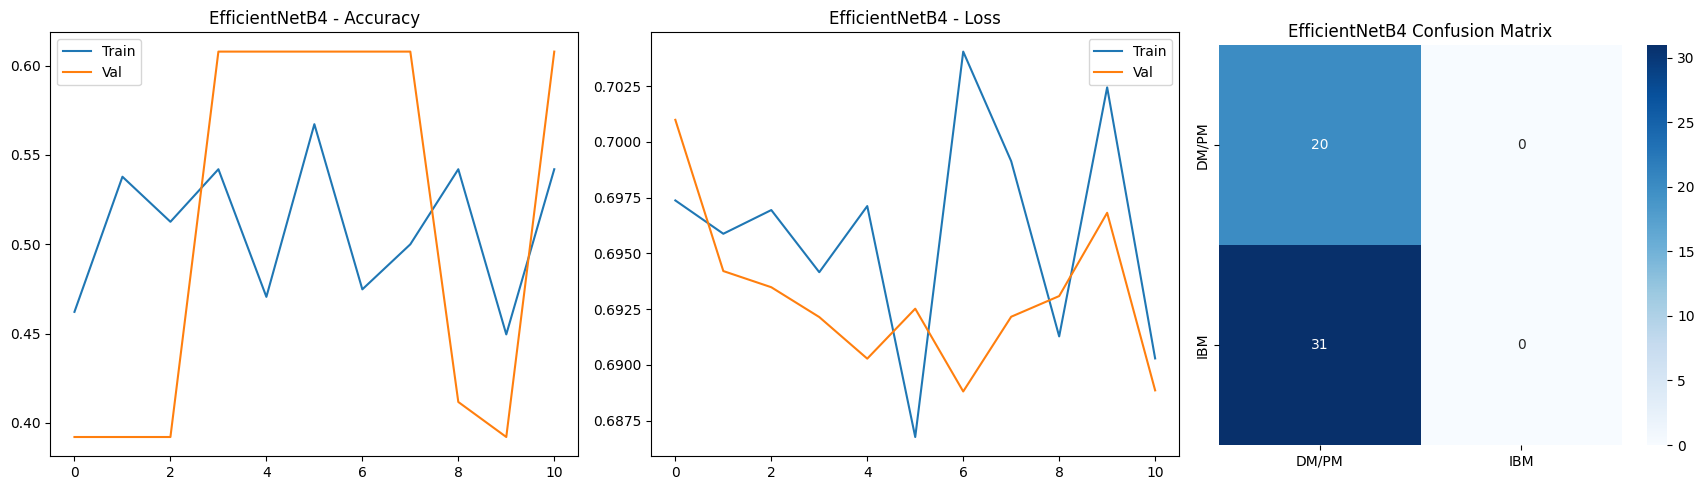

              precision    recall  f1-score   support

       DM/PM       0.39      1.00      0.56        20
         IBM       0.00      0.00      0.00        31

    accuracy                           0.39        51
   macro avg       0.20      0.50      0.28        51
weighted avg       0.15      0.39      0.22        51

{
  "model": "EfficientNetB4",
  "test_acc": 0.3922,
  "test_auc": 0.6726,
  "f1_macro": 0.2817,
  "best_val_acc": 0.6078,
  "best_val_auc": 0.7371,
  "epochs": 11
}

  Training: DenseNet121
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.5924 - auc: 0.5994 - loss: 0.7065 - val_accuracy: 0.6078 - val_auc: 0.4766 - val_loss: 0.6904 - learning_rate: 1.0000e-05
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5714 - auc: 0.5685 - loss: 0.7166 - val_accuracy: 0.5882 - val_auc: 0.5040 - val_loss: 0.6825 - learning_rate: 1.0000e-05
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5042 - auc: 0.5376 - loss: 0.7329 - val_accuracy: 0.

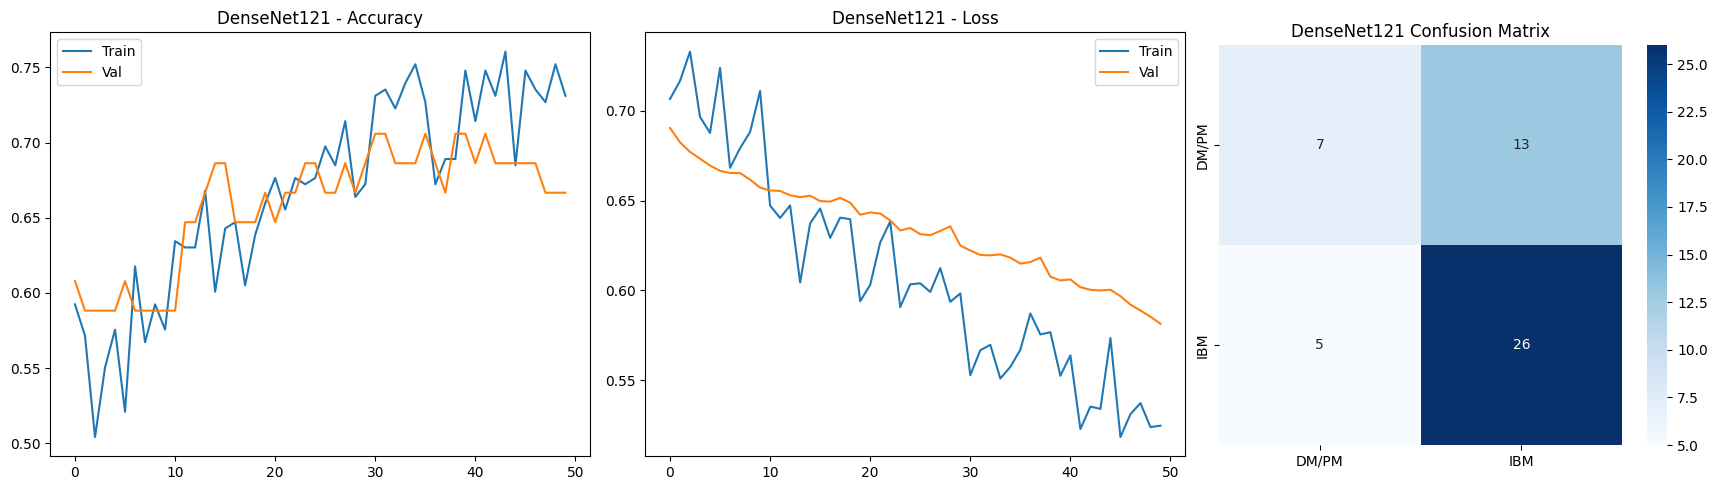

              precision    recall  f1-score   support

       DM/PM       0.58      0.35      0.44        20
         IBM       0.67      0.84      0.74        31

    accuracy                           0.65        51
   macro avg       0.62      0.59      0.59        51
weighted avg       0.63      0.65      0.62        51

{
  "model": "DenseNet121",
  "test_acc": 0.6471,
  "test_auc": 0.6637,
  "f1_macro": 0.5902,
  "best_val_acc": 0.7059,
  "best_val_auc": 0.7323,
  "epochs": 50
}

  Training: InceptionV3
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5000 - auc: 0.4389 - loss: 0.8094 - val_accuracy: 0.5098 - val_auc: 0.5008 - val_loss: 0.7059 - learning_rate: 1.0000e-05
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5252 - auc: 0.6495 - loss: 0.6790 - val_accuracy: 0.5490 - val_auc: 0.5516 - val_loss: 0.6861 - learning_rate: 1.0000e-05
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6597 - auc: 0.7185 - loss: 0.6227 - val_accuracy: 0.568

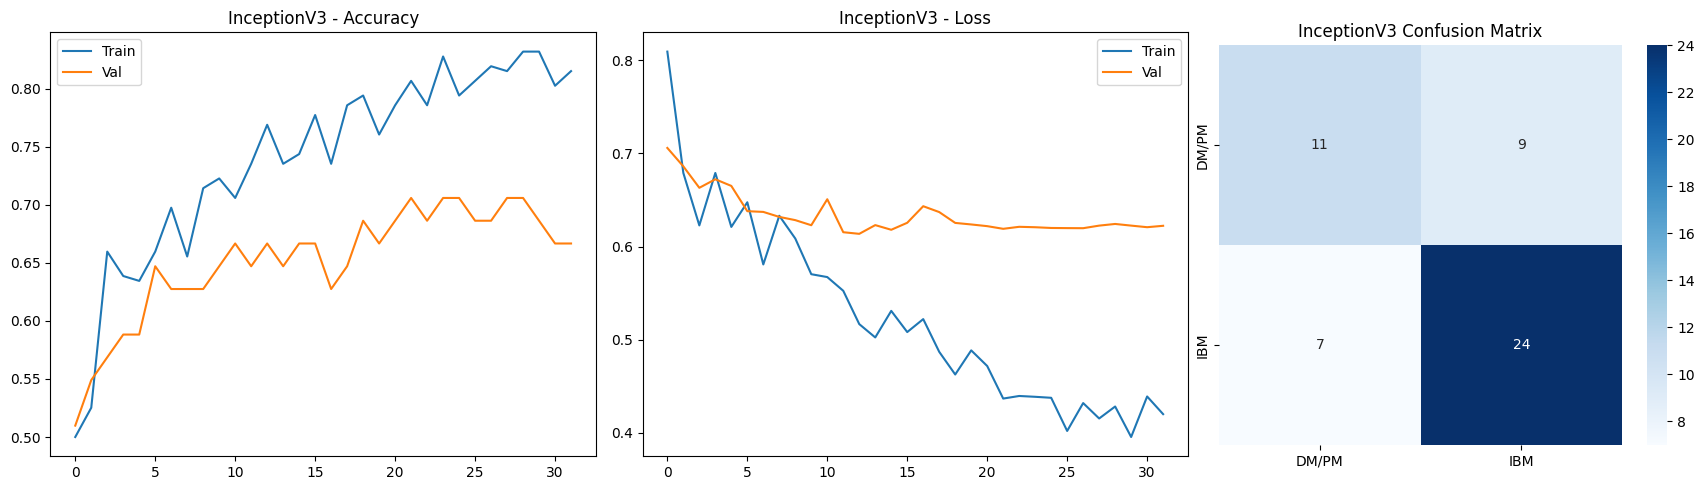

              precision    recall  f1-score   support

       DM/PM       0.61      0.55      0.58        20
         IBM       0.73      0.77      0.75        31

    accuracy                           0.69        51
   macro avg       0.67      0.66      0.66        51
weighted avg       0.68      0.69      0.68        51

{
  "model": "InceptionV3",
  "test_acc": 0.6863,
  "test_auc": 0.6532,
  "f1_macro": 0.6645,
  "best_val_acc": 0.7059,
  "best_val_auc": 0.7153,
  "epochs": 32
}

  Training: Xception
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 73s 7s/step - accuracy: 0.6092 - auc: 0.5527 - loss: 0.6944 - val_accuracy: 0.3922 - val_auc: 0.5306 - val_loss: 0.7388 - learning_rate: 1.0000e-05
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.5294 - auc: 0.5608 - loss: 0.6840 - val_accuracy: 0.3922 - val_auc: 0.5589 - val_loss: 0.7537 - learning_rate: 1.0000e-05
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step - accuracy: 0.5462 - auc: 0.6734 - loss: 0.6618 - val_accuracy: 0.4118 -

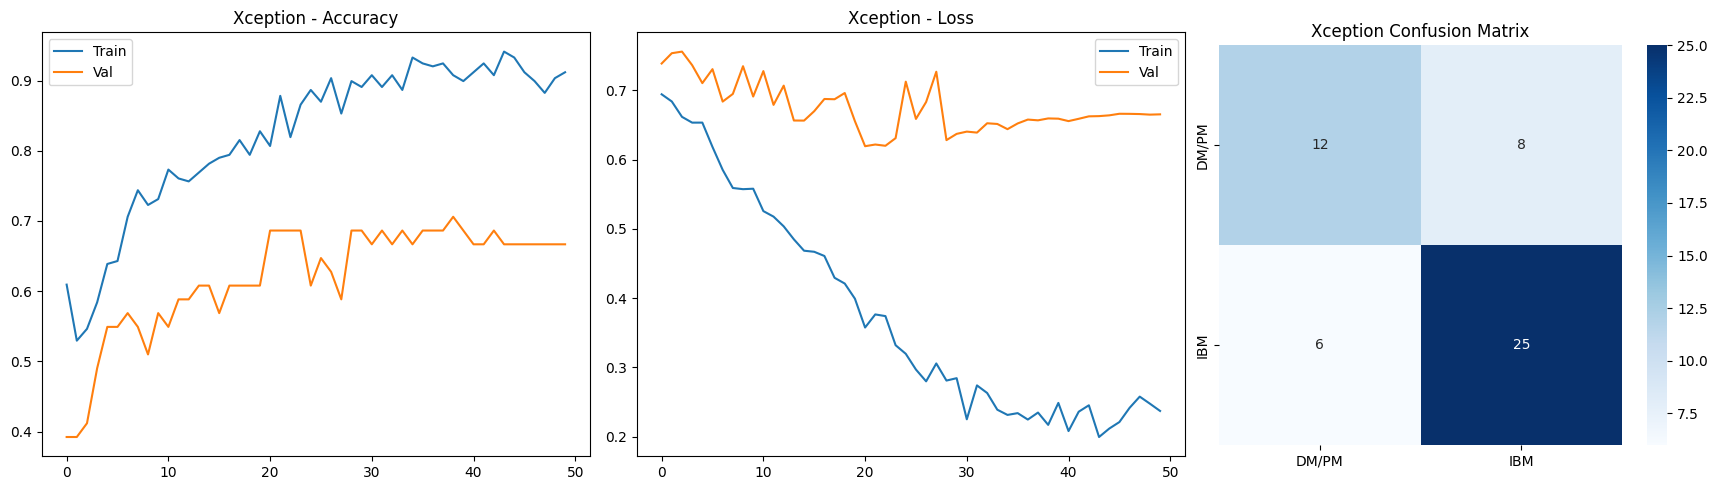

              precision    recall  f1-score   support

       DM/PM       0.67      0.60      0.63        20
         IBM       0.76      0.81      0.78        31

    accuracy                           0.73        51
   macro avg       0.71      0.70      0.71        51
weighted avg       0.72      0.73      0.72        51

{
  "model": "Xception",
  "test_acc": 0.7255,
  "test_auc": 0.746,
  "f1_macro": 0.7064,
  "best_val_acc": 0.7059,
  "best_val_auc": 0.7492,
  "epochs": 50
}

All models done!


In [7]:
all_results = []

for model_name in MODELS_TO_RUN:
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    keras.backend.clear_session()
    model = build_binary_model(model_name)

    ckpt_path = os.path.join(RESULTS_DIR, f'{model_name}_best.keras')
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=10,
                                       restore_best_weights=True, mode='max'),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5,
                                           factor=0.5, min_lr=1e-7),
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_auc',
                                         save_best_only=True, mode='max'),
        keras.callbacks.CSVLogger(os.path.join(RESULTS_DIR, f'{model_name}_log.csv')),
    ]

    history = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        class_weight=class_weight, callbacks=callbacks, verbose=1
    )

    # ── Evaluate
    test_metrics = model.evaluate(test_ds, verbose=0)
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_prob  = model.predict(test_ds, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    f1 = f1_score(y_true, y_pred, average='macro')

    # ── Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, key, title in zip(axes, ['accuracy','loss','auc'],
                                      ['Accuracy','Loss','AUC']):
        ax.plot(history.history[key],      label='Train')
        ax.plot(history.history[f'val_{key}'], label='Val')
        ax.set_title(f'{model_name} - {title}'); ax.legend()
    cm = confusion_matrix(y_true, y_pred)
    axes[2].set_visible(False)
    fig.add_axes([0.68, 0.1, 0.28, 0.8])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'{model_name}_results.png'), dpi=120)
    plt.show()

    result = {
        'model': model_name,
        'test_acc': round(test_metrics[1], 4),
        'test_auc': round(test_metrics[2], 4),
        'f1_macro': round(f1, 4),
        'best_val_acc': round(max(history.history['val_accuracy']), 4),
        'best_val_auc': round(max(history.history['val_auc']), 4),
        'epochs': len(history.history['accuracy']),
    }
    all_results.append(result)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    print(json.dumps(result, indent=2))

print("\nAll models done!")

## Model Comparison Table

         model  test_acc  test_auc  f1_macro  best_val_acc  best_val_auc  epochs
      Xception    0.7255    0.7460    0.7064        0.7059        0.7492      50
   InceptionV3    0.6863    0.6532    0.6645        0.7059        0.7153      32
   DenseNet121    0.6471    0.6637    0.5902        0.7059        0.7323      50
      ResNet50    0.6078    0.6532    0.3780        0.8039        0.7766      13
EfficientNetB0    0.6078    0.5000    0.3780        0.6275        0.5000      11
     ResNet101    0.3922    0.6565    0.2817        0.6667        0.7379      11
EfficientNetB4    0.3922    0.6726    0.2817        0.6078        0.7371      11


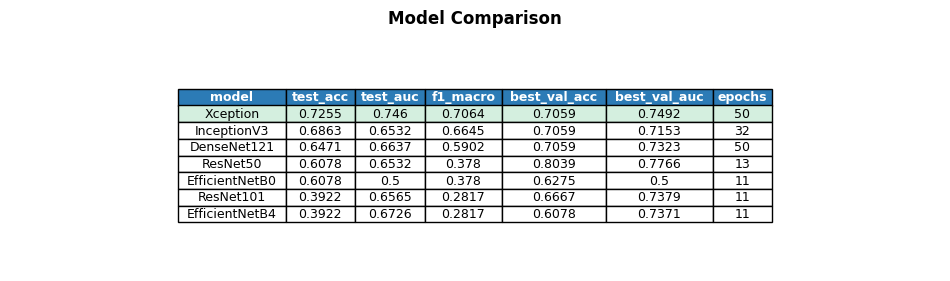

Comparison table saved.


In [8]:
df_res = pd.DataFrame(all_results).sort_values('test_acc', ascending=False)
df_res.to_csv(os.path.join(RESULTS_DIR, 'comparison.csv'), index=False)
print(df_res.to_string(index=False))

# Plot comparison table
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
tbl = ax.table(cellText=df_res.values, colLabels=df_res.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(df_res.columns))))
for j in range(len(df_res.columns)):
    tbl[0, j].set_facecolor('#2c7bb6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4efdf')
plt.title('Model Comparison', fontweight='bold', pad=12)
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Comparison table saved.")